In [116]:
import pandas as pd
from utils import compare_poly, get_season
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [117]:
# Load the data
kpi_df = pd.read_feather('../data/kpi_df.feather').reset_index()
weather_df = pd.read_feather('../data/weather_burbank_airport.feather')

In [118]:
kpi_df.head()

,index,local_hour,total_kWh,session_count
0,0,2018-04-25 04:00:00-07:00,3.094930,1
1,1,2018-04-25 05:00:00-07:00,3.575657,1
2,2,2018-04-25 06:00:00-07:00,3.161296,3
3,3,2018-04-25 07:00:00-07:00,10.509661,8
4,4,2018-04-25 08:00:00-07:00,41.767757,22


In [119]:
weather_df.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0,2018-01-01 01:00:00-08:00
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0,2018-01-01 02:00:00-08:00
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0,2018-01-01 03:00:00-08:00
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0,2018-01-01 04:00:00-08:00
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0,2018-01-01 05:00:00-08:00


In [120]:
# Take only charging data from the beginnnig of 2018 to March 2020 (before the pandemic)
kpi_df = kpi_df[(kpi_df["local_hour"] >= "2018-01-01") & (kpi_df["local_hour"] < "2020-03-01")]

In [121]:
# Merge the two dataframes by timestamp
merged_df = kpi_df.merge(weather_df, left_on="local_hour", right_on="rounded_timestamp", how="left")

In [122]:
merged_df.head()

,index,local_hour,total_kWh,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,0,2018-04-25 04:00:00-07:00,3.094930,1,Burbank,2018-04-25 03:53:00-07:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0,2018-04-25 04:00:00-07:00
1,1,2018-04-25 05:00:00-07:00,3.575657,1,Burbank,2018-04-25 04:53:00-07:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0,2018-04-25 05:00:00-07:00
2,2,2018-04-25 06:00:00-07:00,3.161296,3,Burbank,2018-04-25 05:53:00-07:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0,2018-04-25 06:00:00-07:00
3,3,2018-04-25 07:00:00-07:00,10.509661,8,Burbank,2018-04-25 06:53:00-07:00,12.0,20.0,Fog,989.44,7.0,0.0,12.0,2018-04-25 07:00:00-07:00
4,4,2018-04-25 08:00:00-07:00,41.767757,22,Burbank,2018-04-25 07:53:00-07:00,12.0,26.0,Cloudy,990.10,6.0,0.0,12.0,2018-04-25 08:00:00-07:00


In [123]:
len(merged_df)

15789

In [124]:
# Check for null values
missing_values_merged = merged_df.isnull().sum()
missing_values_merged

index                       0
local_hour                  0
total_kWh                   1
session_count               0
city                       40
timestamp                  40
temperature                40
cloud_cover                40
cloud_cover_description    40
pressure                   40
windspeed                  40
precipitation              40
felt_temperature           40
rounded_timestamp          40
dtype: int64

There are 40 rows with missing weather data. We will drop these rows to be able to train the models.

In [125]:
# Drop rows with missing weather data 
merged_df = merged_df.dropna()

In [126]:
len(merged_df)

15748

In [127]:
merged_df.head()

,index,local_hour,total_kWh,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,0,2018-04-25 04:00:00-07:00,3.094930,1,Burbank,2018-04-25 03:53:00-07:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0,2018-04-25 04:00:00-07:00
1,1,2018-04-25 05:00:00-07:00,3.575657,1,Burbank,2018-04-25 04:53:00-07:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0,2018-04-25 05:00:00-07:00
2,2,2018-04-25 06:00:00-07:00,3.161296,3,Burbank,2018-04-25 05:53:00-07:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0,2018-04-25 06:00:00-07:00
3,3,2018-04-25 07:00:00-07:00,10.509661,8,Burbank,2018-04-25 06:53:00-07:00,12.0,20.0,Fog,989.44,7.0,0.0,12.0,2018-04-25 07:00:00-07:00
4,4,2018-04-25 08:00:00-07:00,41.767757,22,Burbank,2018-04-25 07:53:00-07:00,12.0,26.0,Cloudy,990.10,6.0,0.0,12.0,2018-04-25 08:00:00-07:00


We have merged the data. Now we have to prepare it for the machine learning model by encoding and normalizing the data.
We define hourly utilization of the stations as the number of vehicles charged in that hour. Therefore, we will use the KPI session_count as the target variable for the model.

In [156]:
model_df = merged_df.copy()

In [157]:
# Calculate time related features
model_df["hour"] = model_df["local_hour"].dt.hour
model_df['is_weekend'] = model_df['local_hour'].dt.weekday >= 5
model_df["season"] = model_df["local_hour"].apply(get_season)
model_df["weekday"] = model_df["local_hour"].dt.weekday
model_df["month"] = model_df["local_hour"].dt.month

In [158]:
# Drop columns that are not needed for the model
model_df = model_df.drop(columns=["index", 'timestamp', 'rounded_timestamp', "city", "felt_temperature", "local_hour"])

In [159]:
# Distribution of values in cloud_cover_description
model_df["cloud_cover_description"].value_counts()

cloud_cover_description
Fair                       9539
Cloudy                     2625
Partly Cloudy              1782
Mostly Cloudy               926
Light Rain                  304
Haze                        269
Smoke                        75
Fog                          70
Rain                         46
Fair / Windy                 37
Heavy Rain                   26
Partly Cloudy / Windy        10
Cloudy / Windy                8
Mostly Cloudy / Windy         8
T-Storm                       6
Light Rain / Windy            5
Blowing Dust                  5
Thunder in the Vicinity       4
Heavy Rain / Windy            2
Heavy T-Storm                 1
Name: count, dtype: int64

Before One Hot Encoding, we have to check the distribution of the categorical data in the column cloud_cover_description. As it can be seen above, there are a high number of unique values, which will result in a high number of columns after one hot encoding. The higher the number of features/dimensions the longer will it take to train the model. Therefore, we will merge the "/ Windy" columns with the corresponding columns and only keep the most frequent categories.

In [160]:
# Merge the "/ Windy" columns with the corresponding columns
model_df['cloud_cover_description'] = model_df['cloud_cover_description'].str.split(' / Windy').str[0]

# Keep the most frequent categories and merge the rest into "Other"
threshold = 100
model_df.loc[model_df["cloud_cover_description"].value_counts()[model_df["cloud_cover_description"]].values < threshold, "cloud_cover_description"] = "Other"

model_df["cloud_cover_description"].value_counts()

cloud_cover_description
Fair             9576
Cloudy           2633
Partly Cloudy    1792
Mostly Cloudy     934
Light Rain        309
Haze              269
Other             235
Name: count, dtype: int64

In [161]:
# One hot encode categorical data
model_df = pd.get_dummies(model_df, columns=['season'], drop_first=True)
model_df = pd.get_dummies(model_df, columns=['cloud_cover_description'], drop_first=True)

In [162]:
cloud_cover_columns = [col for col in model_df.columns if col.startswith("cloud_cover_description")]

In [163]:
# Encode boolean columns
bool_cols = cloud_cover_columns + ["is_weekend", "season_Spring", "season_Summer", "season_Winter"]
numerical_cols = [col for col in model_df.columns if col not in bool_cols]
model_df[bool_cols] = model_df[bool_cols].astype(int)

In [164]:
model_df.head()

,total_kWh,session_count,temperature,cloud_cover,pressure,windspeed,precipitation,hour,is_weekend,weekday,month,season_Spring,season_Summer,season_Winter,cloud_cover_description_Fair,cloud_cover_description_Haze,cloud_cover_description_Light Rain,cloud_cover_description_Mostly Cloudy,cloud_cover_description_Other,cloud_cover_description_Partly Cloudy
0,3.094930,1,12.0,26.0,989.11,11.0,0.0,4,0,2,4,1,0,0,0,0,0,0,0,0
1,3.575657,1,12.0,27.0,989.11,6.0,0.0,5,0,2,4,1,0,0,0,0,0,1,0,0
2,3.161296,3,12.0,28.0,989.11,9.0,0.0,6,0,2,4,1,0,0,0,0,0,1,0,0
3,10.509661,8,12.0,20.0,989.44,7.0,0.0,7,0,2,4,1,0,0,0,0,0,0,1,0
4,41.767757,22,12.0,26.0,990.10,6.0,0.0,8,0,2,4,1,0,0,0,0,0,0,0,0


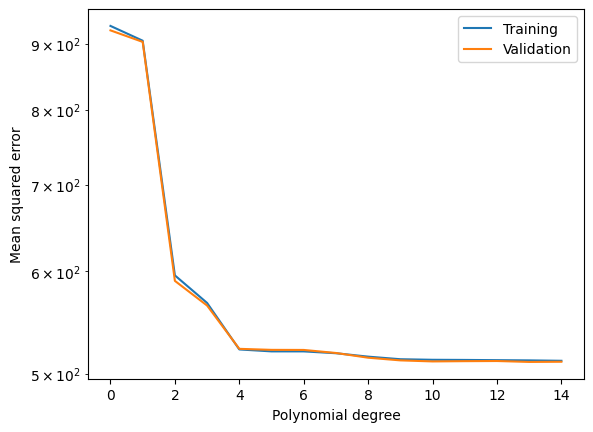

In [186]:
compare_poly(model_df, 'hour', 'session_count', 15)

In [179]:
used_columns = ["hour", "weekday", "is_weekend", "season_Spring", "season_Summer", "season_Winter", "temperature", "cloud_cover", "month", "pressure"]
used_columns_numerical = [col for col in used_columns if col not in bool_cols]
used_columns_boolean = [col for col in used_columns if col in bool_cols]

In [180]:
# Define the features and the target variable
X = model_df[used_columns]
y = model_df["session_count"]

# Split the data into training and testing sets (80% train, 20% test)
X_train_initial, X_test, y_train_initial, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [181]:
#Data Scaling using MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_initial)
X_test_scaled = scaler.transform(X_test)

In [185]:
# --- K-Fold Cross-Validation Setup ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Polynomial Regression with Degree 4 ---
degree = 4
poly = PolynomialFeatures(degree=degree)

# Linear Regression model will act as the base for polynomial regression
linear_model = LinearRegression()

# Lists to store evaluation metrics for each fold
poly_mae_scores = []
poly_r2_scores = []

# Perform K-Fold Cross-Validation for Polynomial Regression
for train_index, val_index in kf.split(X_train_initial):
    
    X_train, X_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_train, y_val = y_train_initial.iloc[train_index], y_train_initial.iloc[val_index]
    
    # Transform the features into polynomial features
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    
    # Train the model
    linear_model.fit(X_train_poly, y_train)
    
    # Predict on the validation set
    y_pred_val = linear_model.predict(X_val_poly)
    
    # Calculate RMSE and R² for the fold
    mae = mean_absolute_error(y_val, y_pred_val)
    r2 = r2_score(y_val, y_pred_val)
    
    # Store the metrics for later analysis
    poly_mae_scores.append(mae)
    poly_r2_scores.append(r2)

# Transform the entire training and test sets
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train the polynomial regression model on the entire training set
linear_model.fit(X_train_poly, y_train_initial)

# Predict on the test set
y_pred_poly = linear_model.predict(X_test_poly)

# Calculate MSE, RMSE, and R² on the test set for Polynomial Regression
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

# Print evaluation results
print("Polynomial Regression (Degree 4) - Cross-validated MAE: ", np.mean(poly_mae_scores))
print("Polynomial Regression (Degree 4) - Test MAE: ", poly_mae)
print("Polynomial Regression (Degree 4) - Cross-validated R²: ", np.mean(poly_r2_scores))
print("Polynomial Regression (Degree 4) - Test R²: ", poly_r2)

Polynomial Regression (Degree 4) - Cross-validated MAE:  9.57123490247256
Polynomial Regression (Degree 4) - Test MAE:  9.344320223369296
Polynomial Regression (Degree 4) - Cross-validated R²:  0.8226303993066224
Polynomial Regression (Degree 4) - Test R²:  0.8302767403153358


In [53]:
# --- 2. Neural Network Model ---
nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Lists to store evaluation metrics for each fold
nn_rmse_scores = []
nn_r2_scores = []

# Perform K-Fold Cross-Validation for Neural Network
for train_index, val_index in kf.split(X_train_initial):
    X_train, X_val = X_train_scaled[train_index], X_train_scaled[val_index] 
    y_train, y_val = y_train_initial.iloc[train_index], y_train_initial.iloc[val_index]
    
    # Train the model
    nn_model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred_val = nn_model.predict(X_val)
    
    # Calculate RMSE and R² for the fold
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    # Store the metrics for later analysis
    nn_rmse_scores.append(rmse)
    nn_r2_scores.append(r2)

# Train the neural network model on the entire training set
nn_model.fit(X_train_initial, y_train_initial)

# Predict on the test set
y_pred_nn = nn_model.predict(X_test)

# Calculate MSE, RMSE, and R² on the test set for Neural Network
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test, y_pred_nn)

print("Neural Network - Cross-validated RMSE: ", np.mean(nn_rmse_scores))
print("Neural Network - Test RMSE: ", nn_rmse)
print("Neural Network - Cross-validated R²: ", np.mean(nn_r2_scores))
print("Neural Network - Test R²: ", nn_r2)

Neural Network - Cross-validated RMSE:  14.809539358130715
Neural Network - Test RMSE:  15.58056276452626
Neural Network - Cross-validated R²:  0.7632681632111809
Neural Network - Test R²:  0.7375896932839268
